# Post-Impact Pluto-Charon: Thermal-Orbital Evolution

Charon is thought to have formed in a giant impact and to have been left on an eccentric orbit close to Pluto, with both bodies spinning fast (Canup 2005; Denton et al. 2025 place the post-impact orbit near 2.5 Pluto radii). This notebook follows the pair from such a start to today with `System.evolve`, both bodies raising tides on each other and both evolving their spins and layer temperatures:

* Charon's orbit at $a_0 = 10\,R_P$ and $e_0 = 0.5$, beyond the radius of Denton et al., where the bundled worlds' interiors stay meaningful;
* Pluto's spin set by today's total angular momentum (orbit plus both spins), Charon spinning at 5 times the orbital motion;
* tides of degrees 2 and 3, each run separately, with the eccentricity truncation following $e$ (50 at $e = 0.5$, falling to 2 once the orbit is nearly circular);
* the bundled `pluto` and `charon`, each a rocky core under a two-phase `ice_ih` hydrosphere that melts and freezes inside its own radii, warmed at the start (Pluto's hydrosphere at 268.2 K, an ocean under a 100 km shell; Charon's at 265 K);
* the run starts 100 Myr after formation (radiogenic heat counts from formation) and ends 4.5 Gyr after it.

The evolution is integrated in stages: each `evolve` call continues from the state the last one left, so the truncation can drop as $e$ falls and each stage is saved. A full run takes hours; with `RUN = False` the saved stages are loaded instead.

In [1]:
%matplotlib inline
import os
import time

import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G, year
from TidalPy.Structures import build_system, build_world
from TidalPy.Tides.eccentricity.eccentricity_driver import recommend_eccentricity_truncation
from TidalPy.Utilities.logging import set_log_level

set_log_level("error")
MYR = 1.0e6 * year
R_PLUTO = 1188.3e3   # [m]
RUN = not all(os.path.exists(f"pluto_charon_post_impact_deg{degree}.npz") for degree in (2, 3))

## The Starting State

The total angular momentum of today's system (Charon's orbit, $a = 16.5\,R_P$ and nearly circular, plus the two synchronous spins) is kept: with the post-impact orbit and Charon's spin chosen, it sets Pluto's spin. The orbit-averaged tides conserve it, so the run should end near today's orbit if the pair circularizes and locks.

In [2]:
def angular_momentum(system):
    pluto, charon = system["pluto"], system["charon"]
    mp, mc = pluto.mass, charon.mass
    a, e = system.get_semi_major_axis("pluto"), system.get_eccentricity("pluto")
    orbit = mp * mc / (mp + mc) * np.sqrt(G * (mp + mc) * a * (1.0 - e * e))
    return orbit + sum(world.get_moment_of_inertia() * world.spin_frequency for world in (pluto, charon))


def build_post_impact(max_degree, a0_radii=10.0, e0=0.5, charon_spin_ratio=5.0):
    system = build_system("pluto_charon_system")
    for world in system:
        if len(world) > 0:
            world.solve_eos()
    momentum = angular_momentum(system)
    pluto, charon = system["pluto"], system["charon"]
    pluto["hydrosphere"].temperature = 268.197
    charon["hydrosphere"].temperature = 265.0
    for world in (pluto, charon):
        world.set_tide_config(max_degree_l=max_degree, eccentricity_truncation=50)
    system.set_semi_major_axis("pluto", a0_radii * R_PLUTO)
    system.set_eccentricity("pluto", e0)
    for world in (pluto, charon):
        world.solve_eos(solve_temperature=True, surface_temperature=system.calc_equilibrium_temperature(world))
    n0 = system.calc_orbital_frequency("pluto")
    charon.set_spin_frequency(charon_spin_ratio * n0)
    spin_momentum = momentum - angular_momentum(system) + pluto.get_moment_of_inertia() * pluto.spin_frequency
    pluto.set_spin_frequency(spin_momentum / pluto.get_moment_of_inertia())
    return system


today = build_system("pluto_charon_system")
system = build_post_impact(2)
n0 = system.calc_orbital_frequency("pluto")
print(f"today: a = {today.get_semi_major_axis('pluto') / R_PLUTO:.2f} R_P, "
      f"orbital period {2 * np.pi / today.calc_orbital_frequency('pluto') / 86400:.3f} d")
print(f"start: a = {system.get_semi_major_axis('pluto') / R_PLUTO:.1f} R_P, e = {system.get_eccentricity('pluto')}, "
      f"orbital period {2 * np.pi / n0 / 3600:.1f} h, Pluto spin {system['pluto'].spin_frequency / n0:.2f} n, "
      f"Charon spin {system['charon'].spin_frequency / n0:.2f} n")

today: a = 16.49 R_P, orbital period 6.387 d
start: a = 10.0 R_P, e = 0.5, orbital period 72.4 h, Pluto spin 14.57 n, Charon spin 5.00 n


## Staged Evolution

`evolve` runs from the current state over a stage and leaves the system at the stage's end. Before each stage the eccentricity truncation is set to the tabulated level at or above the one `recommend_eccentricity_truncation` gives for $1.1\,e$ (the levels are 2, 4, 6, 8, 10, 20, and 50). The stages start at 10 years and double up to 100 Myr. Each stage's steps are appended to the record, which is saved after every stage.

In [3]:
LEVELS = (2, 4, 6, 8, 10, 20, 50)


def truncation_for(e):
    wanted = recommend_eccentricity_truncation(1.1 * e)
    if not isinstance(wanted, int):   # 'exact' past e = 0.55; 50 is the level recommended at 0.5
        return LEVELS[-1]
    return next((level for level in LEVELS if level >= wanted), LEVELS[-1])


def evolve_staged(degree, t0=100.0, t_end=4500.0, first_stage=1.0e-5, longest_stage=100.0):
    system = build_post_impact(degree)
    names = ("pluto", "charon")
    record = {key: [] for key in ("t", "a", "e", "truncation")}
    record.update({f"{name}_{key}": [] for name in names for key in ("spin", "heating", "T")})
    t, stage, level, start = t0, first_stage, None, time.perf_counter()
    while t < t_end:
        if truncation_for(system.get_eccentricity("pluto")) != level:
            level = truncation_for(system.get_eccentricity("pluto"))
            for name in names:
                system[name].set_tide_config(eccentricity_truncation=level)
        pair = system.evolve("charon", (t * MYR, min(t + stage, t_end) * MYR))
        keep = slice(1, None) if record["t"] else slice(None)
        record["t"].append(pair.time[keep] / MYR)
        record["a"].append(pair.semi_major_axis[keep])
        record["e"].append(pair.eccentricity[keep])
        record["truncation"].append(np.full(pair.time[keep].size, level))
        for name in names:
            record[f"{name}_spin"].append(pair[name].spin_ratio[keep])
            record[f"{name}_heating"].append(pair[name].tidal_heating[keep])
            record[f"{name}_T"].append(pair[name].temperature[:, keep].T)
        np.savez(f"pluto_charon_post_impact_deg{degree}.npz",
                 **{key: np.concatenate(value) for key, value in record.items()})
        if not pair.success:
            print(pair.message)
            break
        t = pair.time[-1] / MYR
        stage = min(2.0 * stage, longest_stage)
    print(f"degree {degree}: reached {t:.4g} Myr in {(time.perf_counter() - start) / 3600:.2f} h")


if RUN:
    for degree in (2, 3):
        evolve_staged(degree)
runs = {degree: dict(np.load(f"pluto_charon_post_impact_deg{degree}.npz")) for degree in (2, 3)}
for degree, run in runs.items():
    print(f"degree {degree}: {run['t'].size} steps to {run['t'][-1]:.4g} Myr; final a = {run['a'][-1] / R_PLUTO:.3f} R_P, "
          f"e = {run['e'][-1]:.3e}, spins {run['pluto_spin'][-1]:.8f} and {run['charon_spin'][-1]:.8f} n")

degree 2: 1590 steps to 1768 Myr; final a = 16.568 R_P, e = 1.568e-26, spins 1.00000000 and 1.00000000 n
degree 3: 2303 steps to 4500 Myr; final a = 16.568 R_P, e = 3.494e-26, spins 1.00000000 and 1.00000000 n


## Orbit

The tides raised on Charon damp the eccentricity, and those raised on Pluto, spinning faster than the orbit, push Charon outward. The dashed line is today's semi-major axis.

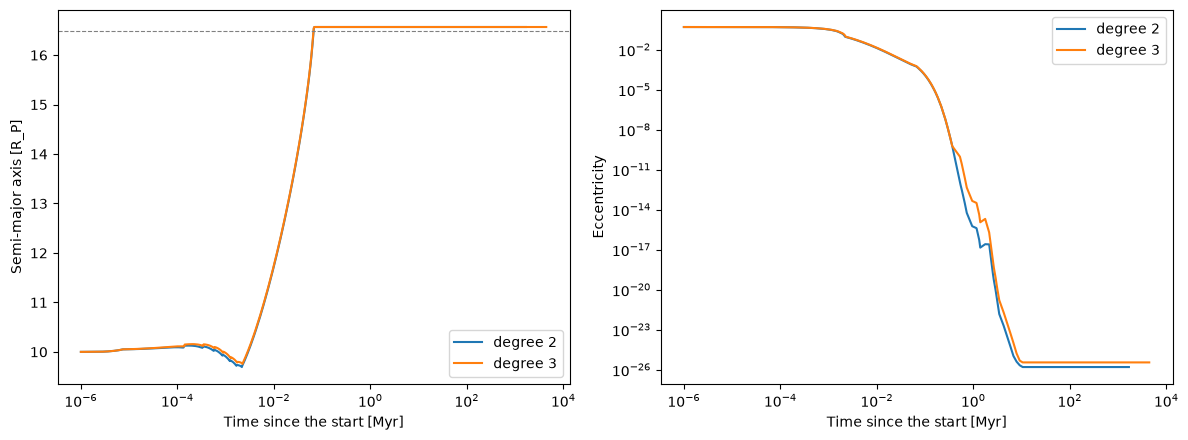

In [4]:
fig, (ax_a, ax_e) = plt.subplots(1, 2, figsize=(12, 4.5))
for degree, run in runs.items():
    elapsed = run["t"] - run["t"][0] + 1.0e-6
    ax_a.plot(elapsed, run["a"] / R_PLUTO, label=f"degree {degree}")
    ax_e.plot(elapsed, run["e"], label=f"degree {degree}")
ax_a.axhline(today.get_semi_major_axis("pluto") / R_PLUTO, color="0.5", ls="--", lw=0.8)
for ax in (ax_a, ax_e):
    ax.set_xscale("log")
    ax.set_xlabel("Time since the start [Myr]")
    ax.legend()
ax_e.set_yscale("log")
ax_a.set_ylabel("Semi-major axis [R_P]")
ax_e.set_ylabel("Eccentricity")
fig.tight_layout()
plt.show()

## Spins

Each spin ratio (spin frequency over the orbital motion) falls from its post-impact value toward synchrony, holding at spin-orbit equilibria on the way where a resonant mode's torque can hold it.

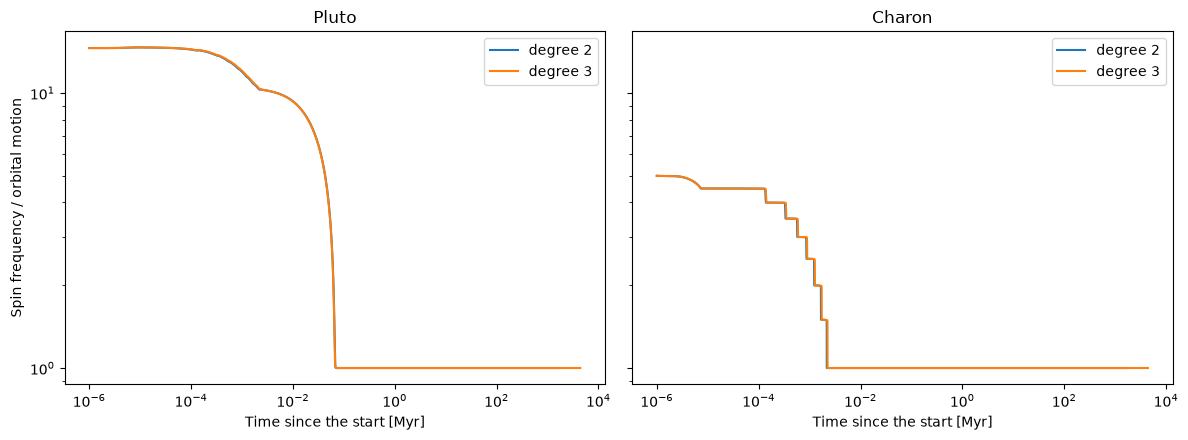

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, name in zip(axes, ("pluto", "charon")):
    for degree, run in runs.items():
        ax.plot(run["t"] - run["t"][0] + 1.0e-6, run[f"{name}_spin"], label=f"degree {degree}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Time since the start [Myr]")
    ax.set_title(name.capitalize())
    ax.legend()
axes[0].set_ylabel("Spin frequency / orbital motion")
fig.tight_layout()
plt.show()

## Heating and Temperatures

Tidal heating in each body, and the temperature of each layer (core and hydrosphere).

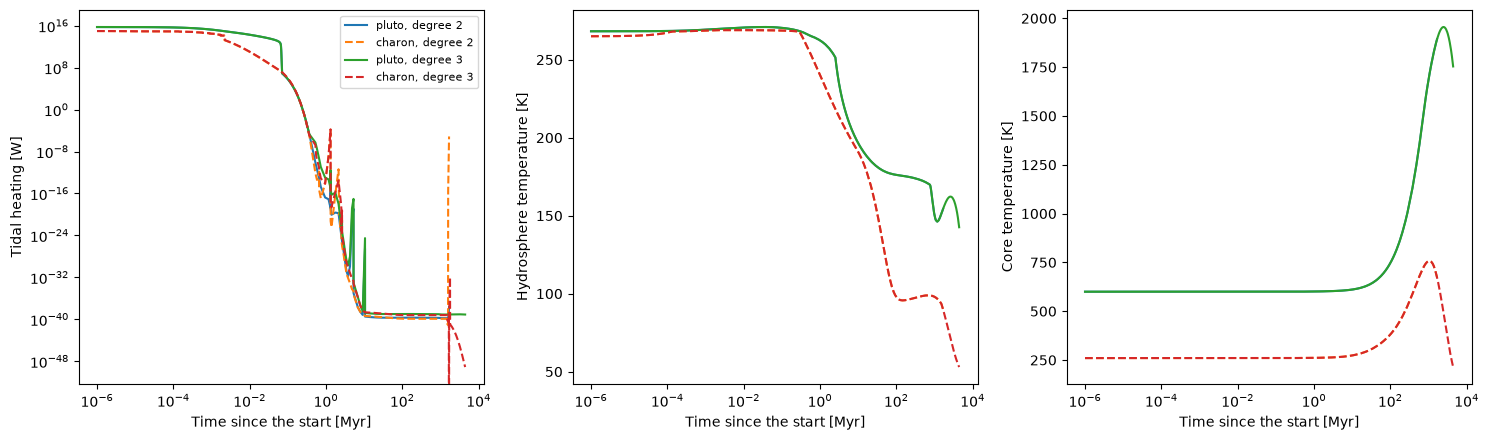

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for degree, run in runs.items():
    elapsed = run["t"] - run["t"][0] + 1.0e-6
    for name, style in (("pluto", "-"), ("charon", "--")):
        axes[0].plot(elapsed, run[f"{name}_heating"], style, label=f"{name}, degree {degree}")
        axes[1].plot(elapsed, run[f"{name}_T"][:, 1], style, label=f"{name}, degree {degree}")
        axes[2].plot(elapsed, run[f"{name}_T"][:, 0], style, label=f"{name}, degree {degree}")
for ax, label in zip(axes, ("Tidal heating [W]", "Hydrosphere temperature [K]", "Core temperature [K]")):
    ax.set_xscale("log")
    ax.set_xlabel("Time since the start [Myr]")
    ax.set_ylabel(label)
axes[0].set_yscale("log")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Effective Q of an Ice Shell

How dissipative are the two bodies? The effective quality factor $Q = \mathrm{Re}(k_2) / -\mathrm{Im}(k_2)$ is shown for each body rebuilt with its bundled core under an ice shell of constant viscosity (shear modulus 3.3 GPa, density 917 kg m$^{-3}$), over a static water ocean of the rest of the hydrosphere or with the whole hydrosphere ice, for a Maxwell and an Andrade ($\alpha = 0.3$, $\zeta = 1$) shell. Two forcings are shown: the post-impact $2(\Omega - n)$ of each body at the start above, and today's orbital motion $n$, the frequency of the eccentricity tide on a synchronous body.

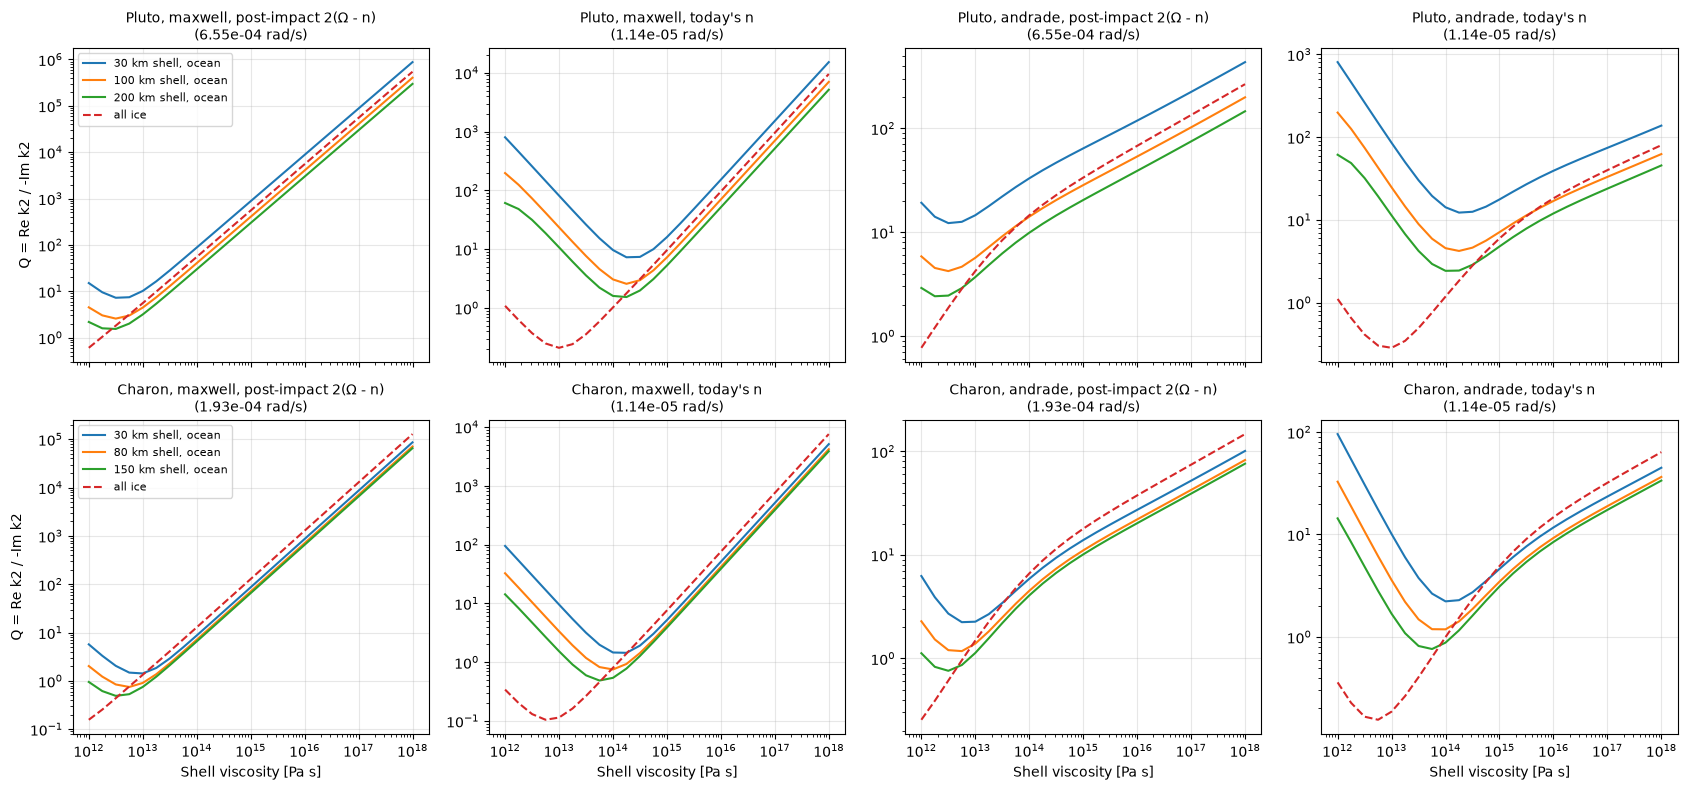

In [7]:
def shell_world(name, shell_km, viscosity, rheology, ocean):
    config = build_world(name).get_config_dict()
    radius = config["radius_m"]
    layers = {"core": config["layers"]["core"]}
    if ocean:
        layers["ocean"] = {
            "layer_index": 1, "radius_outer_m": radius - 1.0e3 * shell_km, "use_tides": False, "is_static": True,
            "temperature_k": 273.0,
            "material": {"liquid": {"eos": {"model": "birch_murnaghan", "reference_density_kg_m3": 999.84,
                                            "reference_bulk_modulus_pa": 1.937e9, "bulk_modulus_derivative": 6.84,
                                            "thermal_expansion_1_k": 0.0}}}}
    layers["shell"] = {
        "layer_index": len(layers), "radius_fraction": 1.0, "state": "solid", "use_tides": True, "temperature_k": 250.0,
        "material": {"solid": {
            "eos": {"model": "birch_murnaghan", "reference_density_kg_m3": 917.0, "reference_bulk_modulus_pa": 9.0e9,
                    "bulk_modulus_derivative": 5.5, "thermal_expansion_1_k": 0.0},
            "shear_modulus": {"model": "constant", "shear_modulus_pa": 3.3e9},
            "shear_viscosity": {"model": "constant", "reference_viscosity_pas": viscosity}}},
        "shear_rheology": {"model": "maxwell"} if rheology == "maxwell" else {"model": "andrade", "alpha": 0.3, "zeta": 1.0}}
    config["layers"] = layers
    config["name"] = f"{name}, {shell_km:g} km shell"
    world = build_world(config)
    world.solve_eos(solve_temperature=False)
    return world


start_state = build_post_impact(2)
forcings = {name: {"post-impact 2(Ω - n)": 2.0 * (start_state[name].spin_frequency - n0),
                   "today's n": today.calc_orbital_frequency("pluto")} for name in ("pluto", "charon")}
shells = {"pluto": (30.0, 100.0, 200.0), "charon": (30.0, 80.0, 150.0)}
viscosities = np.logspace(12, 18, 25)
fig, axes = plt.subplots(2, 4, figsize=(17, 8), sharex=True)
for row, name in enumerate(("pluto", "charon")):
    for column, (rheology, forcing) in enumerate([(r, f) for r in ("maxwell", "andrade") for f in forcings[name]]):
        ax = axes[row, column]
        frequency = forcings[name][forcing]
        cases = [(f"{shell:g} km shell, ocean", shell, True) for shell in shells[name]] + [("all ice", shells[name][0], False)]
        for label, shell, ocean in cases:
            k2 = np.array([shell_world(name, shell, eta, rheology, ocean).calc_love_numbers([frequency])["k"][0]
                           for eta in viscosities])
            ax.loglog(viscosities, k2.real / -k2.imag, ls="-" if ocean else "--", label=label)
        ax.set_title(f"{name.capitalize()}, {rheology}, {forcing}\n({frequency:.2e} rad/s)", fontsize=10)
        ax.grid(True, which="major", alpha=0.3)
        if row == 1:
            ax.set_xlabel("Shell viscosity [Pa s]")
        if column == 0:
            ax.set_ylabel("Q = Re k2 / -Im k2")
    axes[row, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Discussion

Both runs tell the same story, the two degrees agreeing to a few percent in every time below.

* **Charon locks first.** The tides raised on Charon damp the eccentricity on a kyr timescale ($e < 0.1$ after about 2.2 kyr, $e < 0.01$ after 12 kyr, $e < 10^{-4}$ after about 0.1 Myr). Charon despins through 5:1, 9:2, ..., 3:2 without being held and locks synchronous at about 2.2 kyr, while the orbit briefly shrinks to about $9.7\,R_P$.
* **Pluto follows.** Spinning about 14 times faster than the orbit, Pluto raises tides that push Charon outward and despin Pluto through its own half-integer ratios (and, at degree 3, the thirds). It locks at about 70 kyr, and the orbit ends double synchronous and circular at $16.57\,R_P$. Today's orbit is $16.49\,R_P$. The agreement follows from the starting state, which keeps today's total angular momentum, and checks the integration's conservation of it rather than the post-impact scenario.
* **Heat.** Tidal heating peaks at the start, $5.5 \times 10^{15}$ W in Pluto and $10^{15}$ W in Charon, and warms both hydrospheres to about 269 to 271 K within tens of kyr. Once both bodies are locked and the orbit is circular the tides stop, and each body cools on its own.

Caveats:

* The bundled thermal setup loses heat from the hydrospheres far faster than radiogenic heat replaces it (a thin conductive lid), so both freeze within a few hundred Myr, while Pluto's core, which has no melting law, warms toward 1800 K. These are properties of the bundled cooling models, not of the tides.
* The degree-2 run stops at 1.77 Gyr. Once Charon is cold, its Love solve at the lowest frequencies is poorly conditioned (a thin warm ice band above the core), and the held lock's rates become too noisy for the integrator; the degree-3 run reaches 4.5 Gyr. Everything before the stop agrees between the two.
* The start at $10\,R_P$ is farther out than the $\sim 2.5\,R_P$ of Denton et al. (2025); a closer start needs interiors that hold up under the stronger tides, and higher truncations.
* The early hydrosphere temperatures (268 and 265 K) are chosen, not derived from the impact.

**References**

* Canup, R. M. (2005). A giant impact origin of Pluto-Charon. *Science*, 307(5709), 546-550.
* Denton, C. A., et al. (2025). Capture of an ancient Charon around Pluto. *Nature Geoscience*.